In [ ]:
# ============================================================
# RF TEMPORAL SIN ID'S
#Autor: Hernan Garcia
#Fecha:1/05/2026
#Actualizacion: 1/05/2026
# ============================================================

In [1]:
# ============================================================
# PASO 0 — LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_curve
)

In [2]:
# -------------------------------------------------------
# 1. Cargar los datos
# -------------------------------------------------------
# Ruta de tu archivo CSV (ajústala a tu disco)

BASEFINALAGRUPADA = pd.read_csv(r'C:\Users\garci\OneDrive\Programacion\01.Data\BASEFINALAGRUPADA.csv',
                               sep=';',
                               engine='python'
                               )

In [3]:
# ============================================================
# PASO 1 — BASE
# ============================================================

df = BASEFINALAGRUPADA.copy()
df.columns = df.columns.str.strip()

target_var = "MULTA"
year_var = "AÑO FIRMA CONTRATO"

In [4]:
# ============================================================
# PASO 2 — AJUSTE DE VARIABLES (LOG)
# ============================================================

cat_vars = [
    "ESTADO CONTRATO",
    "TIPO DE CONTRATO",
    "MODALIDAD DE CONTRATACION",
    "JUSTIFICACION DEL CONTRATO",
    "DEPARTAMENTO ENTIDAD CONTRATANTE",
    "SECTOR ECONOMICO ENTIDAD CONTRATANTE",
    "TIPO DE EMPRESA CONTRATISTA",
    "DEPARTAMENTO CONTRATISTA"
]

dummy_vars = [
    "MULTA",
    "OBLIGACIONES AMBIENTALES",
    "OBLIGACIONES POST CONSUMO",
    "OBLIGACIONES POSCONFLICTO",
    "DESTINO GASTO",
    "ORDEN ENTIDAD",
    "AÑO DE ELECCIONES",
    "ELECCIONES PRESIDENCIALES",
    "ELECCIONES DE CONGRESO",
    "ELECCIONES MUNICIPALES"
]

cont_vars = [
    "AÑO FIRMA CONTRATO",
    "AÑO INICIO CONTRATO",
    "AÑO FINAL DEL CONTRATO",
    "SECUESTROS",
    "FINANCIERA",
    "POBLACION EN REINCORPORACION ELN",
    "POBLACION EN REINCORPORACION FARC",
    "POBLACION EN REINCORPORACION PARAMILITARES",
    "POBLACION EN REINCORPORACION OTROS",
    "COMBATE Y/O CONTACTO ARMADO FARC",
    "COMBATE Y/O CONTACTO ARMADO ELN",
    "COMBATE Y/O CONTACTO ARMADO PARAMILITAR",
    "COMBATE Y/O CONTACTO ARMADO OTROS",
    "POBLACION NINI",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO COMPETENCIAS CIUDADANAS",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO COMUNICACION ESCRITA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO ESCRITURA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO INLGES",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO LECTURA CRITICA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO RAZONAMIENTO CUANTITATIVO",
    "DELITOS ELECTORALES",
    "NRO CORRESPONSALES PROPIOS",
    "NRO CORRESPONSALES TERCERIZADOS",
    "NRO CORRESPONSALES ACTIVOS",
    "NRO CORRESPONSALES",
    "NRO GIROS ENVIADOS ",
    "MONTO GIROS ENVIADOS ",
    "NRO GIROS RECIBIDOS",
    "NRO PAGOS",
    "NRO RETIROS",
    "NRO TRANSFERENCIAS",
    "NRO TOTAL ",
    "NRO CTA AHORRO HASTA 1 SMMLV",
    "NRO CTA AHORRO > 1 SMMLV HASTA 3 SMMLV",
    "NRO CTA AHORRO> 3 SMMLV HASTA 5 SMMLV",
    "NRO CTA AHORRO ACTIVAS",
    "NRO CTA AHORRO MUJERES",
    "NRO CTA AHORRO HOMBRES",
    "NRO TOTAL CTA AHORROS",
    "NRO CTA AHORRO ELECTRONICAS ACTIVAS",
    "NRO CTA AHORRO ELECTRONICAS MUJERES",
    "NRO CTA AHORRO ELECTRONICAS HOMBRES",
    "NRO TOTAL CTA AHORROS ELECTRONICAS ",
    "NRO CREDITO CONSUMO MUJERES",
    "MONTO CREDITO CONSUMO MUJERES",
    "NRO CREDITO CONSUMO HOMBRES",
    "MONTO CREDITO CONSUMO  HOMBRES",
    "NRO TOTAL CREDITO CONSUMO",
    "MONTO TOTAL CREDITO CONSUMO",
    "NRO CRED CONS BAJO MONTO MUJERES",
    "NRO CRED CONS BAJO MONTO HOMBRES",
    "NRO TOTAL CRED CONS BAJO MONTO",
    "NRO CREDITO VIVIENDA MUJERES",
    "MONTO CREDITO VIVIENDA MUJERES",
    "NRO CREDITO VIVIENDA HOMBRES",
    "MONTO CREDITO VIVIENDA HOMBRES",
    "NRO TOTAL CREDITO VIVIENDA",
    "NRO MICROCREDITO HASTA 1 SMMLV",
    "MONTO MICROCREDITO HASTA 1 SMMLV",
    "NRO MICROCREDITO > 1 SMMLV HASTA 2 SMMLV",
    "NRO MICROCREDITO> 2 SMMLV HASTA 3 SMMLV",
    "NRO MICROCREDITO> 3 SMMLV HASTA 4 SMMLV",
    "NRO MICROCREDITO> 4 SMMLV HASTA 10 SMMLV",
    "NRO MICROCREDITO> 10SMMLV HASTA 25SMMLV",
    "NRO MICROCREDITO MUJERES",
    "NRO MICROCREDITO HOMBRES",
    "NRO TOTAL MICROCREDITO ",
    "NRO PROD DEPOSITO NIVEL NACIONAL",
    "MONTO PROD DEPOSITO NIVEL NACIONAL"
    
]

index_vars = [
    "IDH",
    "PROMEDIO INDICE IICA",
    "TASA DE ALFABETIZACION",
    "INDICE EFICIENCIA FISCAL",
    "INDICE EFICACIA TOTAL ",
    "INDICE EFICIENCIA TOTAL",
    "INDICE REQUISITOS LEGALES",
    "CAPACIDAD ADMINISTRATIVA"
]

log_vars = [
    "VALOR CONTRATO",
    "PIB AGRICULTURA Y GANADERÍA",
    "PIB EXPLOTACIÓN DE MINAS Y CANTERAS",
    "PIB INDUSTRIAS MANUFACTURERAS",
    "PIB SUMINISTRO DE ELECTRICIDAD, GAS ETC",
    "PIB CONSTRUCCION",
    "PIB COMERCIO AL POR MAYOR Y AL POR MENOR",
    "PIB INFORMACIÓN Y COMUNICACIONES",
    "PIB ACTIVIDADES FINANCIERAS",
    "PIB ACTIVIDADES INMOBILIARIAS",
    "PIB ACTIVIDADES PROFESIONALES",
    "PIB ADMINISTRACIÓN PÚBLICA Y DEFENSA",
    "PIB ACTIVIDADES ARTÍSTICAS",
    "HOMICIDIOS",
    "HURTOS PERSONAS",
    "VIOLENCIA INTRAFAMILIAR",
    "HURTO A VEHICULOS",
    "DELITOS SEXUALES",
    "DELITOS MEDIO AMBIENTE",
    "HURTO A COMERCIOS",
    "RESIDENCIAS",
    "INCAUTACIONES DE ARMAS",
    "DESPLAZADOS PERCAPITA",
    "DESPLAZADOS NUMERO DE CASOS",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS EN UNIVERSIDAD PUBLICA",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS EN UNIVERSIDAD PRIVADA",
    "NUMERO DE MATRICULADOS A EDUCACION SUPERIOR",
    "NUMERO DE ADMITIDOS A EDUCACION SUPERIOR",
    "NUMERO DE INSCRITOS EN UNIVERSIDADES",
    "NUMERO EMPLEADOS ADMINISTRATIVOS",
    "NUMERO DE GRADUADOS",
    "HECTAREAS SEMBRADAS DE COCAINA",
    "DESMANTELAMIENTO DE LABORATORIOS",
    "HECTAREAS ERRADICADAS",
    "ENCAUTACIONES DE DROGA EN GRAMOS",
    "NRO DEPOSITOS",
    "MONTO DEPOSITOS",
    "MONTO GIROS RECIBIDOS",
    "MONTO PAGOS",
    "MONTO RETIROS",
    "MONTO TRANSFERENCIAS",
    "MONTO TOTAL",
    "SALDO CTA AHORRO HASTA 1 SMMLV",
    "SALDO CTA AHORRO> 1 SMMLV HASTA 3 SMMLV",
    "SALDO CTA AHORRO> 3 SMMLV HASTA 5 SMMLV",
    "SALDO CTA AHORRO ACTIVAS",
    "SALDO CTA AHORRO MUJERES",
    "SALDO CTA AHORRO HOMBRES",
    "SALDO TOTAL CTA AHORROS",
    "SALDO CTA AHORRO ELECTRONICAS ACTIVAS",
    "SALDO CTA AHORRO ELECTRONICAS MUJERES",
    "SALDO CTA AHORRO ELECTRONICAS HOMBRES",
    "SALDO TOTAL CTA AHORROS ELECTRONICAS ",
    "MONTO CRED CONS BAJO MONTO MUJERES",
    "MONTO CRED CONS BAJO MONTO HOMBRES",
    "MONTO TOTAL CRED CONS BAJO MONTO",
    "MONTO TOTAL CREDITO VIVIENDA",
    "MONTO MICROCREDITO> 1SMMLV HASTA 2SMMLV",
    "MONTO MICROCREDITO> 2SMMLV HASTA 3SMMLV",
    "MONTO MICROCREDITO> 3SMMLV HASTA 4SMMLV",
    "MONTO MICROCREDITO> 4SMMLV HASTA 10SMML",
    "MONTO MICROCREDI> 10SMMLV HASTA 25SMMLV",
    "MONTO MICROCREDITO MUJERES",
    "MONTO MICROCREDITO HOMBRES",
    "MONTO TOTAL MICROCREDITO"
    
]


In [5]:
# ============================================================
# PASO 3 — TRANSFORMACIONES
# ============================================================

for col in log_vars:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.replace(".", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].clip(lower=0)
        df[col] = np.log1p(df[col])

for col in cont_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in dummy_vars:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

for col in cat_vars:
    if col in df.columns:
        df[col] = df[col].astype(str)

for col in index_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


In [7]:

# ============================================================
# PASO 4 — PLAZO
# ============================================================

if "AÑO INICIO CONTRATO" in df.columns and "AÑO FINAL DEL CONTRATO" in df.columns:

    plazo = (
        df["AÑO FINAL DEL CONTRATO"] - df["AÑO INICIO CONTRATO"]
    ).clip(lower=0)

    df = df.assign(PLAZO_CONTRATO=plazo)

    df = df.drop(columns=[
        "AÑO INICIO CONTRATO",
        "AÑO FINAL DEL CONTRATO"
    ])

# 🔥 DESFRAGMENTAR (CLAVE)
df = df.copy()

In [8]:
# ============================================================
# PASO 5 — SPLIT TEMPORAL
# ============================================================

cut_year = 2020

train_df = df[df[year_var] < cut_year]
test_df  = df[df[year_var] >= cut_year]


In [9]:
# ============================================================
# PASO 6 — X / y
# ============================================================

X_train = train_df.drop(columns=[target_var])
y_train = train_df[target_var]

X_test = test_df.drop(columns=[target_var])
y_test = test_df[target_var]

# eliminar año
X_train = X_train.drop(columns=[year_var], errors="ignore")
X_test  = X_test.drop(columns=[year_var], errors="ignore")


In [11]:
# ============================================================
# ELIMINAR VARIABLES TIPO ID
# ============================================================

keywords_id = ["ID_NOMBRE_CONTRATISTA", "NUMERO CONTRATO", "NIT_NOMBRE_CONTRATANTE"]

id_cols = [
    col for col in X_train.columns
    if any(k in col.upper() for k in keywords_id)
]

print("\nColumnas eliminadas por ser IDs:")
print(id_cols)

# eliminar
X_train = X_train.drop(columns=id_cols, errors="ignore")
X_test  = X_test.drop(columns=id_cols, errors="ignore")


Columnas eliminadas por ser IDs:
['NUMERO CONTRATO', 'NIT_NOMBRE_CONTRATANTE', 'ID_NOMBRE_CONTRATISTA']


In [13]:
# ============================================================
# PASO 7 — ELIMINAR COLUMNAS VACÍAS
# ============================================================

cols_all_nan = X_train.columns[X_train.isna().all()]

X_train = X_train.drop(columns=cols_all_nan)
X_test  = X_test.drop(columns=cols_all_nan)

In [14]:
# ============================================================
# PASO 8 — COLUMNAS
# ============================================================

categorical_cols = [col for col in cat_vars if col in X_train.columns]

numeric_cols = [
    col for col in (cont_vars + log_vars + index_vars + dummy_vars)
    if col in X_train.columns
]

In [15]:
# ============================================================
# PASO 9 — REDUCIR CARDINALIDAD
# ============================================================

for col in categorical_cols:

    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    top = X_train[col].value_counts().nlargest(10).index

    X_train[col] = X_train[col].where(X_train[col].isin(top), "OTROS")
    X_test[col] = X_test[col].where(X_test[col].isin(top), "OTROS")


In [16]:
# ============================================================
# PASO 10 — PREPROCESAMIENTO
# ============================================================

preprocessor = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), categorical_cols),

    ("num", SimpleImputer(strategy="median"), numeric_cols)
], sparse_threshold=1.0)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)


In [17]:
# ============================================================
# PASO 11 — MODELO
# ============================================================

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_enc, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
# ============================================================
# PASO 12 — PROBABILIDADES
# ============================================================

test_probs = model.predict_proba(X_test_enc)[:, 1]

In [22]:
# ============================================================
# PASO 13 — SELECCIÓN ROBUSTA DE THRESHOLD 🔥
# ============================================================

thresholds = np.linspace(0.001, 0.2, 50)

results = []

for t in thresholds:

    y_pred_temp = (test_probs > t).astype(int)

    precision = precision_score(y_test, y_pred_temp, zero_division=0)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(
    results,
    columns=["threshold", "precision", "recall", "f1"]
)

# 🔥 SELECCIÓN ROBUSTA
filtered = results_df[results_df["precision"] > 0.01]

if len(filtered) > 0:
    best = filtered.loc[filtered["recall"].idxmax()]
    print("\nThreshold seleccionado (precision > 1%)")

else:
    print("\n⚠️ No hay thresholds con precision > 1%")
    print("👉 Usando mejor F1")

    best = results_df.loc[results_df["f1"].idxmax()]

print(best)

best_threshold = best["threshold"]



⚠️ No hay thresholds con precision > 1%
👉 Usando mejor F1
threshold    0.200000
precision    0.006344
recall       0.560811
f1           0.012546
Name: 49, dtype: float64


In [23]:
# ============================================================
# PASO 14 — PREDICCIÓN FINAL
# ============================================================
y_pred = (test_probs > best_threshold).astype(int)

print("\nDistribución de predicciones:")
print(pd.Series(y_pred).value_counts())


Distribución de predicciones:
0    353017
1     13083
Name: count, dtype: int64


In [24]:
# ============================================================
# PASO 15 — MÉTRICAS
# ============================================================

print("\nRESULTADOS FINALES:")

print("AUC:", roc_auc_score(y_test, test_probs))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


RESULTADOS FINALES:
AUC: 0.9597250569857634
Precision: 0.006344110677979057
Recall: 0.5608108108108109
F1: 0.012546292797218653


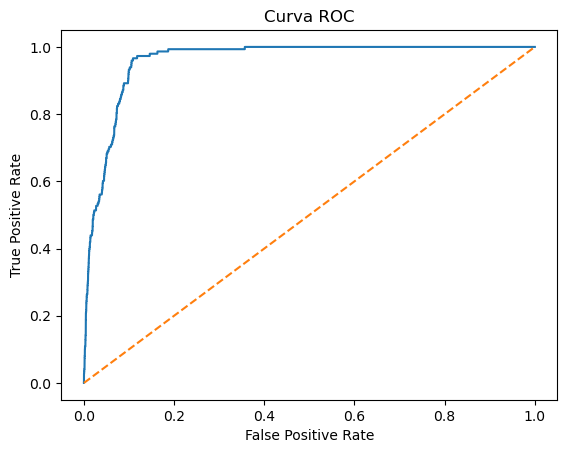

In [32]:
# ============================================================
# PASO 16 — CURVA ROC
# ============================================================

fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

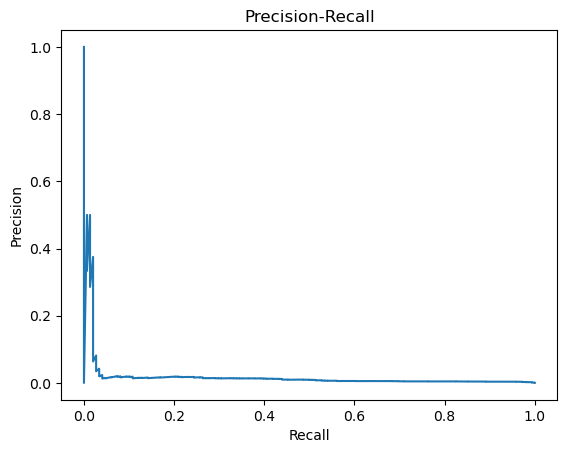

In [26]:
# ============================================================
# PASO 17 — CURVA PRECISION-RECALL
# ============================================================
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probs)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.title("Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [27]:
# ============================================================
# PASO 18 — IMPORTANCIA DE VARIABLES
# ============================================================
feature_names = preprocessor.get_feature_names_out()

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

print("\nTop 10 variables más importantes:")
print(feature_importance.head(10))



Top 10 variables más importantes:
                                         Variable  Importancia
77               cat__DEPARTAMENTO CONTRATISTA_34     0.099824
182  num__MONTO MICROCREDITO> 1SMMLV HASTA 2SMMLV     0.042729
187               num__MONTO MICROCREDITO MUJERES     0.036096
188               num__MONTO MICROCREDITO HOMBRES     0.034843
183  num__MONTO MICROCREDITO> 2SMMLV HASTA 3SMMLV     0.033780
189                 num__MONTO TOTAL MICROCREDITO     0.032977
78                cat__DEPARTAMENTO CONTRATISTA_5     0.030423
181             num__MONTO TOTAL CREDITO VIVIENDA     0.030007
125                           num__VALOR CONTRATO     0.029665
171                 num__SALDO CTA AHORRO ACTIVAS     0.029511


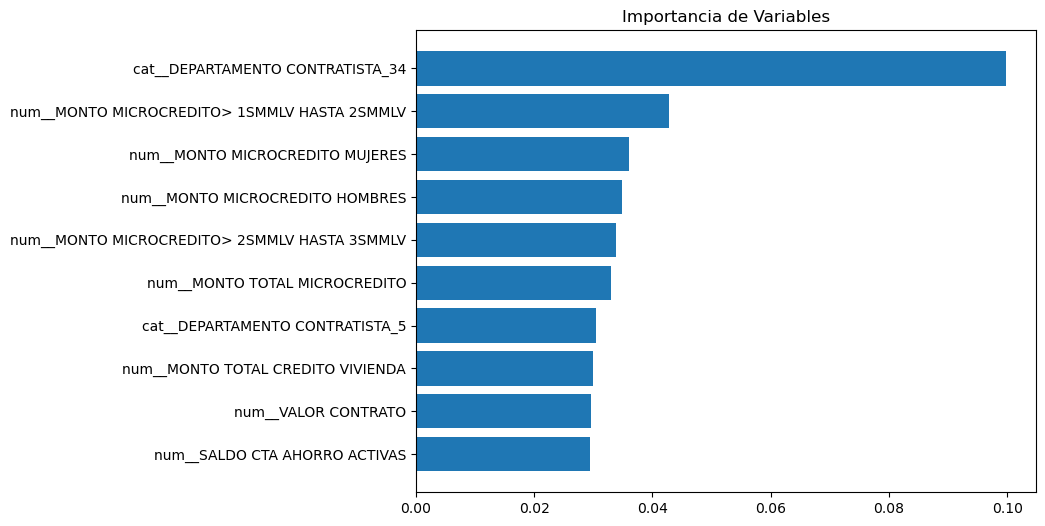

In [29]:
# ============================================================
# PASO 19 — GRÁFICA IMPORTANCIA
# ============================================================

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Variable"], top_features["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables")
plt.show()

In [30]:
# ============================================================
# PASO 20 — ALERTAS
# ============================================================

alertas = pd.DataFrame({
    "Probabilidad": test_probs
})

alertas["Score"] = alertas["Probabilidad"] * 100

alertas["Nivel"] = pd.cut(
    alertas["Score"],
    bins=[0, 10, 30, 60, 100],
    labels=["Bajo", "Medio", "Alto", "Crítico"]
)

print("\nDistribución de alertas:")
print(alertas["Nivel"].value_counts())


Distribución de alertas:
Nivel
Bajo       330487
Medio       32113
Alto         3448
Crítico         5
Name: count, dtype: int64


In [31]:
# ============================================================
# PASO 21 — IMPACTO ECONÓMICO
# ============================================================

if "VALOR CONTRATO" in X_test.columns:

    alertas["Valor_Contrato"] = pd.to_numeric(
        X_test["VALOR CONTRATO"], errors="coerce"
    )

    alertas["Perdida_Esperada"] = (
        alertas["Probabilidad"] * alertas["Valor_Contrato"]
    )

    print("\nTop contratos con mayor riesgo económico:")
    print(alertas.sort_values(
        by="Perdida_Esperada",
        ascending=False
    ).head(10))


Top contratos con mayor riesgo económico:
        Probabilidad      Score    Nivel  Valor_Contrato  Perdida_Esperada
134929      0.563502  56.350249     Alto       27.164121         15.307050
240385      0.559834  55.983411     Alto       25.070622         14.035390
261948      0.642295  64.229467  Crítico       21.822518         14.016487
121771      0.600280  60.027995  Crítico       22.773190         13.670289
118346      0.613674  61.367409  Crítico       22.044488         13.528131
28452       0.583770  58.377023     Alto       22.806762         13.313908
357158      0.585536  58.553628     Alto       22.674164         13.276545
83          0.591212  59.121194     Alto       22.130945         13.084079
231114      0.573075  57.307454     Alto       22.779670         13.054449
67938       0.583770  58.377023     Alto       22.329178         13.035109
